In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def sobel_operators(mu=0, sigma=1):
    sobel_operator_x = np.array([[-norm.pdf(1, loc=mu, scale=sigma), 0, norm.pdf(1, loc=mu, scale=sigma)], [-norm.pdf(0, loc=mu, scale=sigma), 0, norm.pdf(0, loc=mu, scale=sigma)], [-norm.pdf(-1, loc=mu, scale=sigma), 0, norm.pdf(-1, loc=mu, scale=sigma)]])
    sobel_operator_y = np.array([[-norm.pdf(1, loc=mu, scale=sigma), -norm.pdf(0, loc=mu, scale=sigma), -norm.pdf(-1, loc=mu, scale=sigma)], [0, 0, 0], [norm.pdf(1, loc=mu, scale=sigma), norm.pdf(0, loc=mu, scale=sigma), norm.pdf(-1, loc=mu, scale=sigma)]])
    return sobel_operator_x, sobel_operator_y

def convolution(image, kernel):
    '''
    This function performs convolution operation to a gray image. We will consider 3*3 kernel here.
    In general kernel can have shape (2n+1) * (2n+1)  where n>= 0
    image: image (gray)
    kernel: 3*3 convolution kernel
    '''
    r, c = image.shape
    output = np.zeros((r, c))
    
    pad_r = kernel.shape[0] // 2
    pad_c = kernel.shape[1] // 2
    
    pad_img = np.zeros((r + 2*pad_r, c + 2*pad_c))
    pad_img[pad_r:r+pad_r, pad_c:c+pad_c] = image
    kernel = np.flipud(np.fliplr(kernel))
    
    for row in range(pad_r, r+pad_r):
        for col in range(pad_c, c+pad_c):
            patch = pad_img[row-pad_r:row+pad_r+1, col-pad_c:col+pad_c+1]
            output[row-pad_r, col-pad_c] = np.dot(patch.flatten(), kernel.flatten())
    return output

def smoothing_operator(mu=0, sigma=1):
    smoothing_kernel = (1/((norm.pdf(-1, loc=mu, scale=sigma) + norm.pdf(0, loc=mu, scale=sigma) + norm.pdf(1, loc=mu, scale=sigma))**2)) * np.array([[norm.pdf(-1, loc=mu, scale=sigma)*norm.pdf(-1, loc=mu, scale=sigma), norm.pdf(0, loc=mu, scale=sigma)*norm.pdf(-1, loc=mu, scale=sigma), norm.pdf(1, loc=mu, scale=sigma)*norm.pdf(-1, loc=mu, scale=sigma)],
                                                                                                                                                      [norm.pdf(-1, loc=mu, scale=sigma)*norm.pdf(0, loc=mu, scale=sigma), norm.pdf(0, loc=mu, scale=sigma)*norm.pdf(0, loc=mu, scale=sigma), norm.pdf(1, loc=mu, scale=sigma)*norm.pdf(0, loc=mu, scale=sigma)],
                                                                                                                                                      [norm.pdf(-1, loc=mu, scale=sigma)*norm.pdf(1, loc=mu, scale=sigma), norm.pdf(0, loc=mu, scale=sigma)*norm.pdf(1, loc=mu, scale=sigma), norm.pdf(1, loc=mu, scale=sigma)*norm.pdf(1, loc=mu, scale=sigma)]])
    return smoothing_kernel

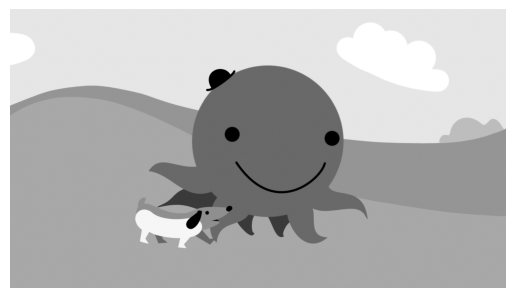

In [3]:
image = cv2.imread("..\Dataset\oswald.png", cv2.IMREAD_GRAYSCALE)
image = image.astype(np.float32) / 255.0
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

### 1. Heuristic Corner Detection via Edge Intersection

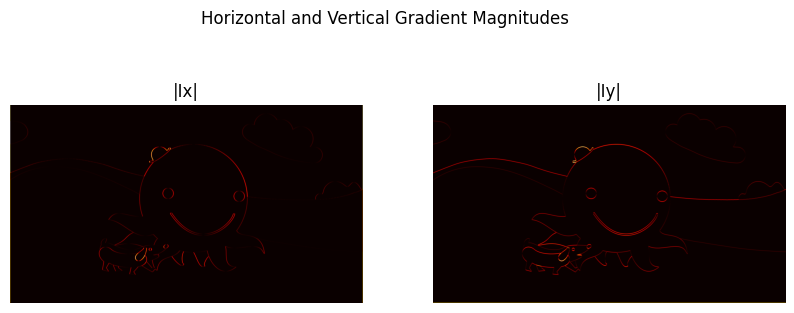

In [4]:
sigma = 1.0
sobel_x, sobel_y = sobel_operators(sigma=sigma)

Ix = convolution(image, sobel_x)
Iy = convolution(image, sobel_y)

mag_Ix = np.abs(Ix)
mag_Iy = np.abs(Iy)

Ix_norm = mag_Ix / np.max(mag_Ix)
Iy_norm = mag_Iy / np.max(mag_Iy)

thresholds = [0.7, 0.8, 0.9]
corner_maps = {}

for t in thresholds:
    corner_map = (Ix_norm > t) & (Iy_norm > t)
    corner_maps[t] = corner_map

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(mag_Ix, cmap='hot')
plt.title('|Ix|')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mag_Iy, cmap='hot')
plt.title('|Iy|')
plt.axis('off')
plt.suptitle('Horizontal and Vertical Gradient Magnitudes')
plt.show()

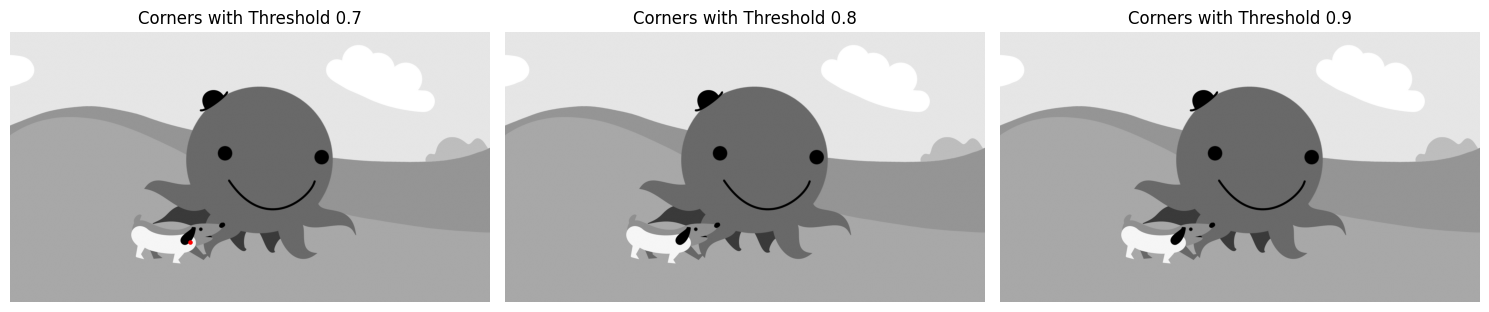

In [5]:
plt.figure(figsize=(15, 5))

for i, t in enumerate(thresholds):
    plt.subplot(1, 3, i + 1)

    plt.imshow(image, cmap="gray")

    y_coords, x_coords = np.where(corner_maps[t])
    plt.scatter(x_coords, y_coords, c="red", s=5)

    plt.title(f'Corners with Threshold {t}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Harris Corner Detection

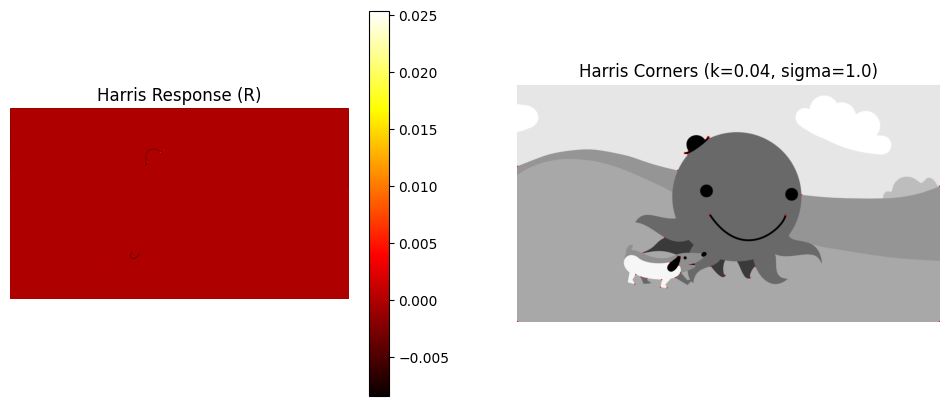

In [6]:
def harris_corner_detector(img, k=0.04, sigma=1.0, threshold_ratio=0.01):
    sobel_x, sobel_y = sobel_operators(sigma=sigma)
    Ix = convolution(img, sobel_x)
    Iy = convolution(img, sobel_y)
    
    Ix2 = Ix ** 2
    Iy2 = Iy ** 2
    Ixy = Ix * Iy
    
    smooth_kernel = smoothing_operator(sigma=sigma)
    S_xx = convolution(Ix2, smooth_kernel)
    S_yy = convolution(Iy2, smooth_kernel)
    S_xy = convolution(Ixy, smooth_kernel)
    
    det_M = (S_xx * S_yy) - (S_xy ** 2)
    trace_M = S_xx + S_yy
    R = det_M - k * (trace_M ** 2)
    
    corners = np.zeros_like(R)
    R_max = R.max()
    threshold = threshold_ratio * R_max
    
    r, c = R.shape
    for i in range(1, r-1):
        for j in range(1, c-1):
            if R[i, j] > threshold:
                if R[i, j] >= R[i-1:i+2, j-1:j+2].max():
                    corners[i, j] = 1
                    
    return corners, R

corners_harris, R_map = harris_corner_detector(image, k=0.04, sigma=1.0)

img_uint8 = (image * 255).astype(np.uint8)
img_color_harris = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)
y_coords, x_coords = np.where(corners_harris == 1)
for x, y in zip(x_coords, y_coords):
    cv2.circle(img_color_harris, (x, y), 2, (0, 0, 255), -1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(R_map, cmap='hot')
plt.title('Harris Response (R)')
plt.colorbar()
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_color_harris, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners (k=0.04, sigma=1.0)')
plt.axis('off')
plt.show()

#### Visualizing different 'k' and 'sigma' parameters

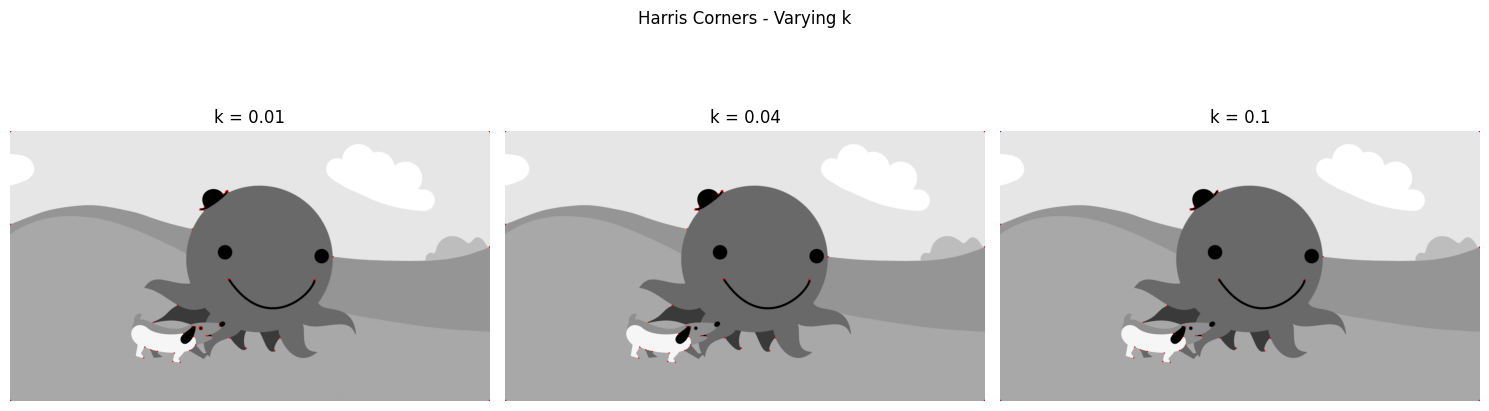

In [7]:
k_values = [0.01, 0.04, 0.1]

img_uint8 = (image * 255).astype(np.uint8)

plt.figure(figsize=(15,5))

for i, k_val in enumerate(k_values):

    corners, _ = harris_corner_detector(image, k=k_val, sigma=1.0)

    img_out = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)

    y_coords, x_coords = np.where(corners == 1)

    for x, y in zip(x_coords, y_coords):
        cv2.circle(img_out, (x, y), 2, (0,0,255), -1)

    plt.subplot(1,3,i+1)
    plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
    plt.title(f'k = {k_val}')
    plt.axis("off")

plt.suptitle("Harris Corners - Varying k")
plt.tight_layout()
plt.show()

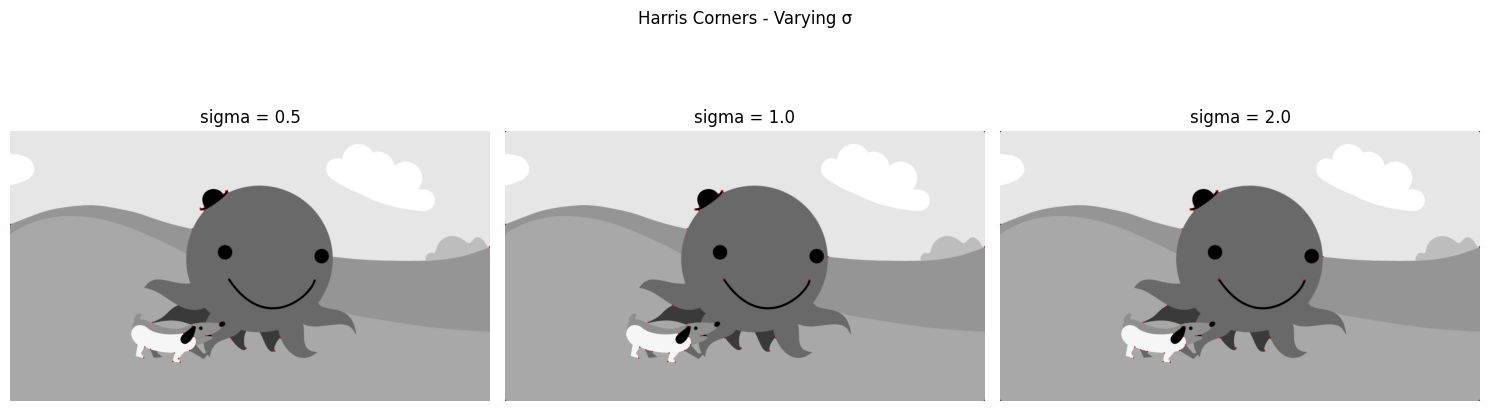

In [8]:
sigma_values = [0.5, 1.0, 2.0]

plt.figure(figsize=(15,5))

for i, sig_val in enumerate(sigma_values):

    corners, _ = harris_corner_detector(image, k=0.04, sigma=sig_val)

    img_out = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)

    y_coords, x_coords = np.where(corners == 1)

    for x, y in zip(x_coords, y_coords):
        cv2.circle(img_out, (x, y), 2, (0,0,255), -1)

    plt.subplot(1,3,i+1)
    plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
    plt.title(f'sigma = {sig_val}')
    plt.axis("off")

plt.suptitle("Harris Corners - Varying σ")
plt.tight_layout()
plt.show()

Influence of Parameters

Effect of k (Harris Sensitivity Parameter)

Smaller k (≈ 0.04)
- Detects more corners  
- May include some edge responses as corners

Larger k (≈ 0.06 – 0.08)
- Produces fewer but stronger corners  
- Suppresses edge-like responses  
- Corners become more selective
 
k controls the trade-off between sensitivity and selectivity of corner detection.

---

Effect of Gaussian Window Size (σ)

Small σ
- Uses a smaller neighborhood
- Detects fine details and small corners
- More sensitive to noise

Large σ
- Averages gradients over a larger region
- Produces more stable corner detection
- May miss small or closely spaced corners
 
σ controls the spatial scale of corner detection.